# Lab 8: Link Prediction with Graph Neural Networks

---

So far in this course every task has been **node-level**: predict a label for each node
given a fixed graph.  In this lab the task shifts to **edges**: given a graph with some
edges held out, can the model decide which pairs of nodes *should* be connected?

This problem is called **link prediction**.  It appears everywhere:
- Social networks suggesting friends you haven't added yet.
- Recommender systems predicting which product a user will buy.
- Biology predicting unknown protein-protein interactions.
- Knowledge-graph completion filling in missing facts.

| Section | Topic | Tasks |
|---------|-------|-------|
| 1 | Link prediction setup and data splitting | — |
| 2 | Evaluation metrics: AUC and AP | — |
| 3 | Variational Graph Autoencoder (VGAE) | — |
| 4 | GraphSAGE-based link predictor | 1, 2, 3 |
| 5 | SEAL: structure-based link prediction | — |

**The core idea in one line:**

$$\hat{y}_{uv} = \text{decode}\left(\mathbf{h}_u^{(L)},\ \mathbf{h}_v^{(L)}\right)$$

The GNN *encodes* each node into an embedding; a lightweight *decoder* turns a pair
of embeddings into an edge score.


---
## 0. Setup

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.metrics import roc_auc_score, average_precision_score

import torch_geometric.transforms as T
from torch_geometric.datasets import Planetoid
from torch_geometric.nn      import GCNConv, SAGEConv, VGAE
from torch_geometric.data    import Data
from torch_geometric.loader  import DataLoader
from torch_geometric.utils   import (k_hop_subgraph, to_scipy_sparse_matrix,
                                      to_networkx, negative_sampling)

import scipy.sparse as sp
from scipy.sparse.csgraph import shortest_path

torch.manual_seed(42)
np.random.seed(42)

c:\Users\PC\miniconda3\envs\graph\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\PC\miniconda3\envs\graph\Lib\site-packages\torch_scatter\_version_cpu.pyd
  import torch_geometric.typing
c:\Users\PC\miniconda3\envs\graph\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\PC\miniconda3\envs\graph\Lib\site-packages\torch_sparse\_version_cpu.pyd
  import torch_geometric.typing
c:\Users\PC\miniconda3\envs\graph\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. Link Prediction Setup

### The self-supervised labelling trick

Link prediction has no external labels.  Instead we:
1. Take the observed edges and designate some as **supervision edges** (the labels).
2. Feed only the remaining **message edges** to the GNN for aggregation.
3. Sample an equal number of **negative edges** (pairs of nodes with no edge) to balance the binary task.

### Why edges must be split *twice*

The lecture showed that for node classification one split suffices.
For link prediction, edges serve two purposes simultaneously — they define the
graph *structure* and they are the *labels* — so a naive split leaks information.

```
Original graph
    ↓  Step 1: designate supervision edges (hold out from GNN)
Message graph  +  supervision edges
    ↓  Step 2: split supervision edges into train / val / test
Train supervision  |  Val supervision  |  Test supervision
```

The model only ever sees message edges during the forward pass; it never "cheats"
by passing messages along the edges it is trying to predict.

### `RandomLinkSplit` does this automatically


In [2]:
# Load Cora; let RandomLinkSplit handle all edge bookkeeping
transform = T.Compose([
    T.NormalizeFeatures(),
    T.RandomLinkSplit(
        num_val               = 0.05,   # 5% of edges → val supervision
        num_test              = 0.10,   # 10% of edges → test supervision
        is_undirected         = True,
        split_labels          = True,   # adds pos/neg_edge_label_index
        add_negative_train_samples = False,  # we'll sample negatives on the fly
    ),
])

dataset    = Planetoid(root='/tmp/Cora', name='Cora', transform=transform)
train_data, val_data, test_data = dataset[0]

print("Split summary")
print(f"  Nodes          : {train_data.num_nodes}")
print(f"  Message edges  (train): {train_data.edge_index.shape[1]}")
print(f"  Supervision +  (train): {train_data.pos_edge_label_index.shape[1]}")
print(f"  Supervision +  (val)  : {val_data.pos_edge_label_index.shape[1]}")
print(f"  Supervision +  (test) : {test_data.pos_edge_label_index.shape[1]}")
print()
print("train_data:", train_data)

Split summary
  Nodes          : 2708
  Message edges  (train): 8976
  Supervision +  (train): 4488
  Supervision +  (val)  : 263
  Supervision +  (test) : 527

train_data: Data(x=[2708, 1433], edge_index=[2, 8976], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708], pos_edge_label=[4488], pos_edge_label_index=[2, 4488])


Original unique undirected edges: 78
Train message edges: 56
Train positive supervision edges: 56
Validation positive supervision edges: 7
Test positive supervision edges: 15

Check:
Train supervision positives are inside train message edges: True
Validation supervision positives are hidden from val message edges: True
Test supervision positives are hidden from test message edges: True


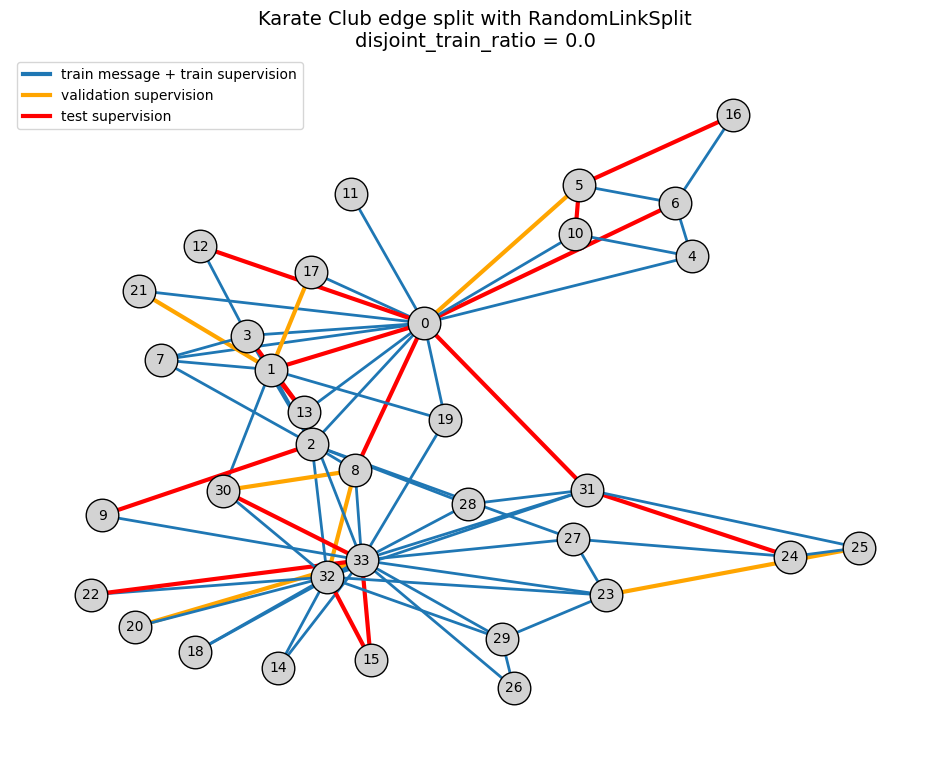

In [3]:
import torch
import networkx as nx
import matplotlib.pyplot as plt

from torch_geometric.datasets import KarateClub
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import to_networkx


# -----------------------------
# 1. Load graph and split edges
# -----------------------------

torch.manual_seed(42)

data = KarateClub()[0]

kc_transform = RandomLinkSplit(
    num_val=0.1,
    num_test=0.2,
    is_undirected=True,
    add_negative_train_samples=True,
    neg_sampling_ratio=1.0,
    disjoint_train_ratio=0.0,
)

kc_train, kc_val, kc_test = kc_transform(data)


# -----------------------------
# 2. Helper functions
# -----------------------------

def to_undirected_edge_set(edge_index):
    """
    Convert PyG edge_index to a set of undirected edges.
    Example: both (u, v) and (v, u) become (min(u, v), max(u, v)).
    """
    edges = edge_index.t().tolist()
    return {
        tuple(sorted((u, v)))
        for u, v in edges
        if u != v
    }


def positive_supervision_edges(split_data):
    """
    Extract only positive edges from edge_label_index.
    Negative sampled edges have label 0 and are not real graph edges.
    """
    pos_mask = split_data.edge_label == 1
    pos_edge_index = split_data.edge_label_index[:, pos_mask]
    return to_undirected_edge_set(pos_edge_index)


# -----------------------------
# 3. Recover edge categories
# -----------------------------

kc_data = KarateClub()[0]
original_edges = to_undirected_edge_set(kc_data.edge_index)

train_message_edges = to_undirected_edge_set(kc_train.edge_index)
val_message_edges = to_undirected_edge_set(kc_val.edge_index)
test_message_edges = to_undirected_edge_set(kc_test.edge_index)

train_supervision_pos = positive_supervision_edges(kc_train)
val_supervision_pos = positive_supervision_edges(kc_val)
test_supervision_pos = positive_supervision_edges(kc_test)

# With disjoint_train_ratio=0.0:
# train supervision positives are the same real edges as train message edges.
# Validation/test supervision positives are hidden from their respective message graphs.

print("Original unique undirected edges:", len(original_edges))
print("Train message edges:", len(train_message_edges))
print("Train positive supervision edges:", len(train_supervision_pos))
print("Validation positive supervision edges:", len(val_supervision_pos))
print("Test positive supervision edges:", len(test_supervision_pos))

print("\nCheck:")
print(
    "Train supervision positives are inside train message edges:",
    train_supervision_pos.issubset(train_message_edges),
)
print(
    "Validation supervision positives are hidden from val message edges:",
    len(val_supervision_pos & val_message_edges) == 0,
)
print(
    "Test supervision positives are hidden from test message edges:",
    len(test_supervision_pos & test_message_edges) == 0,
)


# -----------------------------
# 4. Build NetworkX graph
# -----------------------------

G = nx.Graph()
G.add_nodes_from(range(kc_data.num_nodes))
G.add_edges_from(original_edges)

pos = nx.spring_layout(G, seed=42)


# -----------------------------
# 5. Assign colors by edge role
# -----------------------------

edge_colors = []
edge_widths = []
edge_labels = {}

for edge in G.edges():
    e = tuple(sorted(edge))

    if e in test_supervision_pos:
        edge_colors.append("red")
        edge_widths.append(3.0)
        edge_labels[e] = "test supervision"

    elif e in val_supervision_pos:
        edge_colors.append("orange")
        edge_widths.append(3.0)
        edge_labels[e] = "val supervision"

    elif e in train_supervision_pos:
        # With disjoint_train_ratio=0, these are also message-passing edges.
        edge_colors.append("tab:blue")
        edge_widths.append(2.0)
        edge_labels[e] = "train message + train supervision"

    else:
        edge_colors.append("gray")
        edge_widths.append(1.0)
        edge_labels[e] = "other"


# -----------------------------
# 6. Visualize
# -----------------------------

plt.figure(figsize=(12, 9))

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=550,
    node_color="lightgray",
    edgecolors="black",
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_color="black",
)

nx.draw_networkx_edges(
    G,
    pos,
    edge_color=edge_colors,
    width=edge_widths,
)

plt.title(
    "Karate Club edge split with RandomLinkSplit\n"
    "disjoint_train_ratio = 0.0",
    fontsize=14,
)

# Manual legend
legend_handles = [
    plt.Line2D([0], [0], color="tab:blue", lw=3, label="train message + train supervision"),
    plt.Line2D([0], [0], color="orange", lw=3, label="validation supervision"),
    plt.Line2D([0], [0], color="red", lw=3, label="test supervision"),
]

plt.legend(handles=legend_handles, loc="best")
plt.axis("off")
plt.show()

---
## 2. Evaluation: AUC and AP

Link prediction is a **binary ranking** problem: the model assigns a score to each
candidate edge and we evaluate how well positive edges rank above negative ones.

| Metric | Full name | What it measures |
|--------|-----------|------------------|
| **AUC** | Area Under the ROC Curve | Probability that a random positive edge scores higher than a random negative edge. Random baseline = 0.5. |
| **AP** | Average Precision | Area under the Precision-Recall curve. More informative when negatives vastly outnumber positives. |

Both metrics work *threshold-free*: they look at the **ranking** of scores, not a fixed
decision boundary.  This is important because the number of true edges in a real graph
is tiny compared to all possible node pairs ($|E| \ll \binom{N}{2}$).

```python
from sklearn.metrics import roc_auc_score, average_precision_score

auc = roc_auc_score(y_true, y_score)   # y_score = raw logit or probability
ap  = average_precision_score(y_true, y_score)
```


In [4]:
# Quick illustration of AUC vs accuracy on imbalanced binary data
from sklearn.metrics import roc_auc_score, average_precision_score

np.random.seed(7)
n_pos, n_neg = 100, 5000
y_true  = np.array([1]*n_pos + [0]*n_neg)
# A model that gives slightly better scores to positives
y_score = np.concatenate([np.random.beta(5, 2, n_pos),
                           np.random.beta(2, 5, n_neg)])
y_pred_class = (y_score > 0.5).astype(int)

accuracy = (y_pred_class == y_true).mean()
auc      = roc_auc_score(y_true, y_score)
ap       = average_precision_score(y_true, y_score)

print(f"Accuracy : {accuracy*100:.1f}%  ← high, but 98.4% baseline just by predicting all-negative")
print(f"AUC      : {auc:.3f}          ← reflects actual ranking quality")
print(f"AP       : {ap:.3f}          ← precision-recall quality")

Accuracy : 89.5%  ← high, but 98.4% baseline just by predicting all-negative
AUC      : 0.969          ← reflects actual ranking quality
AP       : 0.634          ← precision-recall quality


---
## 3. Variational Graph Autoencoder (VGAE)

The **Graph Autoencoder** family treats link prediction as reconstruction: encode all
nodes into a latent space, then check whether the dot product of two latent vectors
predicts their edge.

### Architecture

```
Input features X  →  GCN encoder  →  Z (latent embeddings)
Z  →  decoder: σ(Z Zᵀ)  →  reconstructed adjacency Â
```

The **Variational** version (VGAE, Kipf & Welling 2016) adds a regularising prior:
the encoder outputs a *mean* $\mu_v$ and *log-std* $\log\sigma_v$ per node; the
latent code is sampled as $\mathbf{z}_v \sim \mathcal{N}(\mu_v, \sigma_v^2 I)$.

The training objective balances two terms:
$$\mathcal{L} = \underbrace{\text{Reconstruction loss}}_\text{predict edges correctly} + \frac{1}{N}\underbrace{D_{KL}(q(Z|X,A)\,\|\,p(Z))}_\text{keep Z close to N(0,I)}$$

The KL term prevents the encoder from simply memorising the graph.


In [5]:
# The VGAE encoder: two separate output heads for μ and log-σ
class VGAEEncoder(torch.nn.Module):
    def __init__(self, dim_in: int, dim_out: int):
        super().__init__()
        self.conv1       = GCNConv(dim_in, 2 * dim_out)
        self.conv_mu     = GCNConv(2 * dim_out, dim_out)
        self.conv_logstd = GCNConv(2 * dim_out, dim_out)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv_mu(x, edge_index), self.conv_logstd(x, edge_index)

device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vgae_model = VGAE(VGAEEncoder(dataset.num_features, 16)).to(device)
optimizer  = torch.optim.Adam(vgae_model.parameters(), lr=0.01)

train_data_d = train_data.to(device)
val_data_d   = val_data.to(device)
test_data_d  = test_data.to(device)

print(vgae_model)

VGAE(
  (encoder): VGAEEncoder(
    (conv1): GCNConv(1433, 32)
    (conv_mu): GCNConv(32, 16)
    (conv_logstd): GCNConv(32, 16)
  )
  (decoder): InnerProductDecoder()
)


In [6]:
def vgae_train():
    vgae_model.train()
    optimizer.zero_grad()
    z    = vgae_model.encode(train_data_d.x, train_data_d.edge_index)
    loss = (vgae_model.recon_loss(z, train_data_d.pos_edge_label_index)
            + (1 / train_data_d.num_nodes) * vgae_model.kl_loss())
    loss.backward()
    optimizer.step()
    return float(loss)

@torch.no_grad()
def vgae_test(data):
    vgae_model.eval()
    z = vgae_model.encode(data.x, data.edge_index)
    return vgae_model.test(z, data.pos_edge_label_index, data.neg_edge_label_index)

for epoch in range(301):
    loss = vgae_train()
    if epoch % 50 == 0:
        val_auc, val_ap = vgae_test(val_data_d)
        print(f"Epoch {epoch:>3} | Loss: {loss:.4f} | "
              f"Val AUC: {val_auc:.4f} | Val AP: {val_ap:.4f}")

test_auc, test_ap = vgae_test(test_data_d)
print(f"\nVGAE  Test AUC: {test_auc:.4f} | Test AP: {test_ap:.4f}")

C:\Users\PC\AppData\Local\Temp\ipykernel_9124\1068859266.py:9: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  return float(loss)


Epoch   0 | Loss: 3.5064 | Val AUC: 0.6977 | Val AP: 0.7280
Epoch  50 | Loss: 1.3275 | Val AUC: 0.6946 | Val AP: 0.7166
Epoch 100 | Loss: 1.1590 | Val AUC: 0.7622 | Val AP: 0.7712
Epoch 150 | Loss: 1.0382 | Val AUC: 0.8315 | Val AP: 0.8169
Epoch 200 | Loss: 1.0024 | Val AUC: 0.8501 | Val AP: 0.8386
Epoch 250 | Loss: 0.9506 | Val AUC: 0.8605 | Val AP: 0.8519
Epoch 300 | Loss: 0.9336 | Val AUC: 0.8666 | Val AP: 0.8616

VGAE  Test AUC: 0.8843 | Test AP: 0.8719


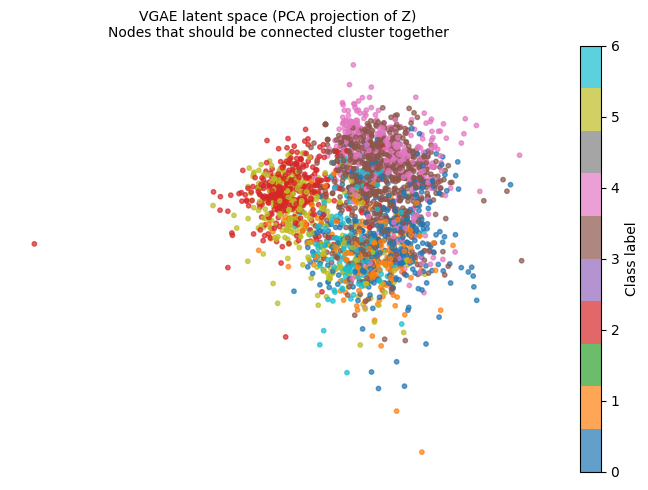

In [7]:
# Visualise the learned latent space (2-D PCA projection)
from sklearn.decomposition import PCA

vgae_model.eval()
with torch.no_grad():
    z = vgae_model.encode(test_data_d.x, test_data_d.edge_index).cpu().numpy()

z2d    = PCA(n_components=2).fit_transform(z)
labels = test_data.y.numpy()

plt.figure(figsize=(7, 5))
scatter = plt.scatter(z2d[:, 0], z2d[:, 1], c=labels,
                      cmap='tab10', s=10, alpha=0.7)
plt.colorbar(scatter, label='Class label')
plt.title("VGAE latent space (PCA projection of Z)\n"
          "Nodes that should be connected cluster together", fontsize=10)
plt.axis('off')
plt.tight_layout()
plt.show()

In [8]:
# What does the reconstructed adjacency look like?
vgae_model.eval()
with torch.no_grad():
    z    = vgae_model.encode(test_data_d.x, test_data_d.edge_index)
    Ahat = torch.sigmoid(z @ z.T).cpu()

print(f"Reconstructed adjacency shape : {list(Ahat.shape)}")
print(f"Score range                   : [{Ahat.min():.3f}, {Ahat.max():.3f}]")
print()
print("Top-5 predicted links for node 0 (excluding self):")
scores = Ahat[0].clone()
scores[0] = -1                   # exclude self-loop
top5 = scores.topk(5).indices.tolist()
print(f"  Predicted neighbours: {top5}")

# Check which are actually connected
actual_neigh = test_data.edge_index[1][test_data.edge_index[0] == 0].tolist()
print(f"  Actual  neighbours  : {actual_neigh[:10]}  (showing up to 10)")

Reconstructed adjacency shape : [2708, 2708]
Score range                   : [0.000, 1.000]

Top-5 predicted links for node 0 (excluding self):
  Predicted neighbours: [1986, 1701, 1810, 598, 1542]
  Actual  neighbours  : [633, 2582, 1862]  (showing up to 10)


---
## 4. GraphSAGE-Based Link Predictor

VGAE uses GCN as its encoder and a fixed dot-product decoder.  In this section we
build a more flexible pipeline:

1. **Encoder**: `GraphSAGE` — the inductive, sampling-friendly encoder from Lecture 8.
2. **Decoder**: a lightweight MLP that scores a (u, v) embedding pair.

The separation is explicit: `GraphSAGE` maps nodes to embeddings; `LinkDecoder`
maps embedding pairs to edge scores.  This modularity makes it easy to swap
either component.

```
X  ──►  GraphSAGE encoder  ──►  Z  (N × d)
                                 │
             (z_u, z_v)  ◄───────┘  (index into Z with edge pairs)
                 │
             LinkDecoder  ──►  scalar score per edge
```

### Negative sampling during training

Because `add_negative_train_samples=False` was set earlier, we call
`negative_sampling` explicitly each epoch on the current message graph.
This means the model sees different negative examples every epoch — a mild
data-augmentation effect.


In [9]:
# GraphSAGE encoder for link prediction.
# Key differences from the node-classification version (Lab 9):
#   1. No classifier head -- we return raw embeddings.
#   2. dropout=0.0 by default: for link prediction the encoder feeds
#      directly into an element-wise product decoder.  With dropout=0.5
#      roughly 75% of product dimensions are zeroed (p_u=0 OR p_v=0),
#      killing gradients before they reach the encoder.
#   3. L2-normalise the output so the dot-product / element-wise product
#      decoder has a predictable input scale regardless of depth or width.

class GraphSAGEEncoder(torch.nn.Module):
    """Two-layer GraphSAGE that returns L2-normalised node embeddings."""

    def __init__(self, dim_in: int, dim_h: int, dim_out: int, dropout: float = 0.0):
        super().__init__()
        self.sage1   = SAGEConv(dim_in, dim_h)
        self.sage2   = SAGEConv(dim_h, dim_out)
        self.dropout = dropout

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        h = F.dropout(x, p=self.dropout, training=self.training)
        h = F.relu(self.sage1(h, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = self.sage2(h, edge_index)
        # L2-normalise: keeps dot-product scores in a stable range
        # regardless of embedding magnitude.
        return F.normalize(h, p=2, dim=-1)

enc = GraphSAGEEncoder(dataset.num_features, 64, 32)
print(enc)
print()
print("dropout = 0.0  (element-wise product kills 75% of dims at p=0.5)")
print("L2 normalisation applied to encoder output")

GraphSAGEEncoder(
  (sage1): SAGEConv(1433, 64, aggr=mean)
  (sage2): SAGEConv(64, 32, aggr=mean)
)

dropout = 0.0  (element-wise product kills 75% of dims at p=0.5)
L2 normalisation applied to encoder output


---
### Task 1 — `dot_product_decode`

Implement the dot-product decoder.  For each edge `(u, v)` in `edge_index`,
compute the **inner product** of the two node embeddings and return a vector of
scalars — one score per edge.

**Algorithm**
1. `z_u = z[edge_index[0]]`  — gather source embeddings, shape `(E, d)`.
2. `z_v = z[edge_index[1]]`  — gather target embeddings, shape `(E, d)`.
3. Return `(z_u * z_v).sum(dim=1)` — element-wise product then sum over `d`.

This is the same decoder used inside `VGAE.recon_loss`, but made explicit so
you can see exactly what happens.


In [10]:
def dot_product_decode(z: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
    """
    Compute the dot-product score for each edge in edge_index.

    Parameters
    ----------
    z          : FloatTensor (N, d)  -- node embeddings
    edge_index : LongTensor  (2, E)  -- edge pairs

    Returns
    -------
    scores : FloatTensor (E,)  -- one scalar per edge (raw logit)

    Example
    -------
    >>> z = torch.eye(4)
    >>> ei = torch.tensor([[0, 1], [1, 0]])
    >>> dot_product_decode(z, ei)
    tensor([1., 1.])
    """
    # Gather source and target embeddings for each edge
    z_u = z[edge_index[0]]          # (E, d)  — source node embeddings
    z_v = z[edge_index[1]]          # (E, d)  — target node embeddings
    # Element-wise product then sum over embedding dimension → inner product
    return (z_u * z_v).sum(dim=1)   # (E,)


In [11]:
# ── Sanity check ──────────────────────────────────────────────────────────
_z  = torch.eye(4)
_ei = torch.tensor([[0, 1, 0], [1, 0, 2]])

_scores = dot_product_decode(_z, _ei)
assert _scores.shape == (3,), f"Expected shape (3,), got {_scores.shape}"
assert abs(_scores[0].item() - 0.0) < 1e-5, "Nodes 0 and 1 are orthogonal → score = 0"
assert abs(_scores[2].item() - 0.0) < 1e-5, "Nodes 0 and 2 are orthogonal → score = 0"

# Same node pair → score equals ||e_0||² = 1
_same = dot_product_decode(_z, torch.tensor([[0], [0]]))
assert abs(_same.item() - 1.0) < 1e-5, "Self-loop score should be 1 for identity matrix"

print("dot_product_decode  ✓")
print("Scores for 3 test edges:", _scores.tolist())

dot_product_decode  ✓
Scores for 3 test edges: [0.0, 0.0, 0.0]


---
### Task 2 — `LinkDecoder` (MLP)

A pure dot-product decoder has no learnable parameters and treats every dimension
of the embedding space equally.  An MLP decoder can learn *which* dimensions matter
most for edge prediction.

Implement `LinkDecoder` — a two-layer MLP that takes the **element-wise product** of
two node embeddings as input and outputs a single logit.

**Architecture**
```
h_uv = z_u * z_v          ← element-wise product, shape (E, d)
→  Linear(d, dim_h) → ReLU → Dropout(0.5) → Linear(dim_h, 1) → squeeze
```

**Algorithm for `forward(z, edge_index)`**
1. `z_u = z[edge_index[0]]`  and  `z_v = z[edge_index[1]]`
2. `h   = z_u * z_v`                         — element-wise product
3. `h   = F.relu(self.lin1(h))`
4. `h   = F.dropout(h, p=0.5, training=self.training)`
5. `h   = self.lin2(h)`
6. Return `h.squeeze(-1)`


In [12]:
class LinkDecoder(torch.nn.Module):
    """
    Two-layer MLP link decoder.

    Takes the element-wise product of two node embeddings as input,
    outputs a single edge logit.

    The Hadamard (element-wise) product is used as the interaction feature
    because it preserves dimensionality and lets the MLP learn which embedding
    dimensions are most discriminative for edge prediction — unlike a fixed
    dot product which treats all dimensions equally.

    Parameters
    ----------
    dim_in  : int   -- embedding dimension (output of the encoder)
    dim_h   : int   -- hidden dimension of the MLP
    """

    def __init__(self, dim_in: int, dim_h: int = 64):
        super().__init__()
        # First linear layer: maps Hadamard product (dim_in) → hidden (dim_h)
        self.lin1 = torch.nn.Linear(dim_in, dim_h)
        # Second linear layer: maps hidden (dim_h) → single logit
        self.lin2 = torch.nn.Linear(dim_h, 1)

    def forward(self, z: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        z          : FloatTensor (N, dim_in)
        edge_index : LongTensor  (2, E)

        Returns
        -------
        FloatTensor (E,) -- raw logit per edge (before sigmoid)
        """
        # Step 1: gather source and target embeddings
        z_u = z[edge_index[0]]            # (E, dim_in)
        z_v = z[edge_index[1]]            # (E, dim_in)

        # Step 2: Hadamard (element-wise) product as pairwise interaction feature
        h = z_u * z_v                     # (E, dim_in)

        # Step 3: two-layer MLP with ReLU activation and dropout regularisation
        h = F.relu(self.lin1(h))          # (E, dim_h)
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.lin2(h)                  # (E, 1)

        # Step 4: remove the trailing dimension → (E,)
        return h.squeeze(-1)


In [13]:
# ── Sanity check ──────────────────────────────────────────────────────────
torch.manual_seed(0)
_dec = LinkDecoder(dim_in=32, dim_h=64)
_z   = torch.randn(10, 32)
_ei  = torch.tensor([[0, 1, 2], [3, 4, 5]])

_out = _dec(_z, _ei)
assert _out.shape == (3,), f"Expected (3,), got {_out.shape}"
print(f"LinkDecoder output shape: {list(_out.shape)}  ✓")
print(f"Sample logits: {_out.detach().tolist()}")

LinkDecoder output shape: [3]  ✓
Sample logits: [0.003751978278160095, -0.030330032110214233, -0.17249426245689392]


---
### Task 3 — Training loop

Now wire the encoder and decoder together into a full training loop.

Complete the function `train_link_predictor` below.  For each epoch it should:

1. **Positive edges**: use `train_data.pos_edge_label_index` (supervision edges held out from message passing).
2. **Negative edges**: sample fresh negatives with `negative_sampling` to avoid memorising a fixed negative set.
3. Concatenate positive and negative edges, build labels (`1` / `0`), compute `BCEWithLogitsLoss`.

**Algorithm**
```
1. z          = encoder(train_data.x, train_data.edge_index)
2. pos_scores = decode(z, pos_edge_label_index)         → (P,)
3. neg_ei     = negative_sampling(train_data.edge_index,
                    num_nodes=train_data.num_nodes,
                    num_neg_samples=pos_edge_label_index.shape[1])
4. neg_scores = decode(z, neg_ei)                       → (N,)
5. scores     = torch.cat([pos_scores, neg_scores])
6. labels     = torch.cat([torch.ones(P), torch.zeros(N)])
7. loss       = criterion(scores, labels)
```


In [14]:
def train_link_predictor(encoder, decoder, train_data, val_data,
                         epochs: int = 200, lr: float = 0.01):
    """
    Train encoder + decoder jointly for link prediction.

    Parameters
    ----------
    encoder    : GraphSAGEEncoder
    decoder    : LinkDecoder  (or callable implementing decode(z, edge_index))
    train_data : PyG Data object with .pos_edge_label_index and .edge_index
    val_data   : PyG Data object with .pos/neg_edge_label_index
    epochs     : int
    lr         : float

    Returns
    -------
    (encoder, decoder)  after training
    """
    params    = list(encoder.parameters()) + list(decoder.parameters())
    optimizer = torch.optim.Adam(params, lr=lr, weight_decay=5e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    for epoch in range(epochs + 1):
        encoder.train(); decoder.train()
        optimizer.zero_grad()

        # ── Step 1: encode all nodes using message-passing edges only ──────
        # train_data.edge_index contains only the message-passing edges;
        # supervision edges are held out to prevent data leakage.
        z = encoder(train_data.x, train_data.edge_index)  # (N, d)

        # ── Step 2: score positive (supervision) edges ────────────────────
        pos_edge_index = train_data.pos_edge_label_index  # (2, P)
        pos_scores = decoder(z, pos_edge_index)            # (P,)

        # ── Step 3: sample fresh negative edges (on-the-fly augmentation) ─
        # Sampling a new negative set each epoch prevents the model from
        # memorising a fixed negative partition and acts as mild data augmentation.
        neg_edge_index = negative_sampling(
            edge_index=train_data.edge_index,
            num_nodes=train_data.num_nodes,
            num_neg_samples=pos_edge_index.shape[1],  # balanced 1:1 ratio
        )                                              # (2, N_neg)
        neg_scores = decoder(z, neg_edge_index)        # (N_neg,)

        # ── Step 4: concatenate scores and build binary labels ─────────────
        scores = torch.cat([pos_scores, neg_scores])   # (P + N_neg,)
        labels = torch.cat([
            torch.ones(pos_scores.shape[0]),
            torch.zeros(neg_scores.shape[0]),
        ]).to(scores.device)                           # (P + N_neg,)

        # ── Step 5: binary cross-entropy loss and backward pass ────────────
        loss = criterion(scores, labels)
        loss.backward()
        optimizer.step()

        if epoch % 20 == 0:
            encoder.eval(); decoder.eval()
            with torch.no_grad():
                val_z      = encoder(val_data.x, val_data.edge_index)
                val_pos    = torch.sigmoid(decoder(val_z, val_data.pos_edge_label_index))
                val_neg    = torch.sigmoid(decoder(val_z, val_data.neg_edge_label_index))
                val_scores = torch.cat([val_pos, val_neg]).numpy()
                val_labels = torch.cat([
                    torch.ones(val_pos.shape[0]),
                    torch.zeros(val_neg.shape[0])
                ]).numpy()
                val_auc = roc_auc_score(val_labels, val_scores)
                val_ap  = average_precision_score(val_labels, val_scores)
            print(f"Epoch {epoch:>3} | Loss: {loss.item():.4f} | "
                  f"Val AUC: {val_auc:.4f} | Val AP: {val_ap:.4f}")
            encoder.train(); decoder.train()

    return encoder, decoder


In [15]:
torch.manual_seed(42)
enc = GraphSAGEEncoder(dataset.num_features, 64, 32)
dec = LinkDecoder(dim_in=32, dim_h=64)

enc, dec = train_link_predictor(enc, dec, train_data, val_data, epochs=200)

Epoch   0 | Loss: 0.6933 | Val AUC: 0.5533 | Val AP: 0.6000
Epoch  20 | Loss: 0.6880 | Val AUC: 0.5855 | Val AP: 0.6353
Epoch  40 | Loss: 0.5809 | Val AUC: 0.6540 | Val AP: 0.6770
Epoch  60 | Loss: 0.4029 | Val AUC: 0.7174 | Val AP: 0.6943
Epoch  80 | Loss: 0.1960 | Val AUC: 0.8378 | Val AP: 0.8300
Epoch 100 | Loss: 0.1815 | Val AUC: 0.8392 | Val AP: 0.8498
Epoch 120 | Loss: 0.1460 | Val AUC: 0.8789 | Val AP: 0.8881
Epoch 140 | Loss: 0.1080 | Val AUC: 0.8789 | Val AP: 0.8963
Epoch 160 | Loss: 0.0828 | Val AUC: 0.8765 | Val AP: 0.8995
Epoch 180 | Loss: 0.0663 | Val AUC: 0.8787 | Val AP: 0.9022
Epoch 200 | Loss: 0.0566 | Val AUC: 0.8808 | Val AP: 0.9063


In [16]:
# ── Evaluate on the held-out test set ─────────────────────────────────────
enc.eval(); dec.eval()

with torch.no_grad():
    z         = enc(test_data.x, test_data.edge_index)
    pos_scores = torch.sigmoid(dec(z, test_data.pos_edge_label_index))
    neg_scores = torch.sigmoid(dec(z, test_data.neg_edge_label_index))

all_scores = torch.cat([pos_scores, neg_scores]).numpy()
all_labels = torch.cat([
    torch.ones(pos_scores.shape[0]),
    torch.zeros(neg_scores.shape[0])
]).numpy()

sage_lp_auc = roc_auc_score(all_labels, all_scores)
sage_lp_ap  = average_precision_score(all_labels, all_scores)

print(f"GraphSAGE + MLP decoder  Test AUC: {sage_lp_auc:.4f} | Test AP: {sage_lp_ap:.4f}")
print(f"VGAE (dot product)       Test AUC: {test_auc:.4f}  | Test AP: {test_ap:.4f}")

GraphSAGE + MLP decoder  Test AUC: 0.8692 | Test AP: 0.8941
VGAE (dot product)       Test AUC: 0.8843  | Test AP: 0.8719


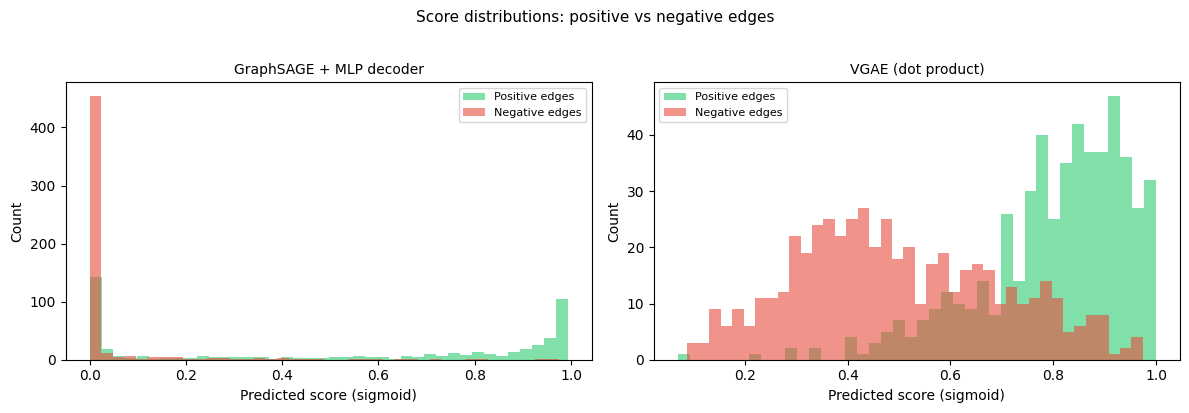

In [17]:
# ── Visualise score distributions ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, scores, neg_s, title in zip(
    axes,
    [pos_scores.numpy(), all_scores[:len(pos_scores)]],
    [neg_scores.numpy(), all_scores[len(pos_scores):]],
    ["GraphSAGE + MLP decoder", "VGAE (dot product)"],
):
    if title == "VGAE (dot product)":
        with torch.no_grad():
            zv = vgae_model.encode(test_data_d.x, test_data_d.edge_index)
            ps = torch.sigmoid(dot_product_decode(zv.cpu(), test_data.pos_edge_label_index)).numpy()
            ns = torch.sigmoid(dot_product_decode(zv.cpu(), test_data.neg_edge_label_index)).numpy()
        scores = ps; neg_s = ns

    ax.hist(scores, bins=40, alpha=0.6, color='#2ecc71', label='Positive edges')
    ax.hist(neg_s,  bins=40, alpha=0.6, color='#e74c3c', label='Negative edges')
    ax.set_xlabel('Predicted score (sigmoid)')
    ax.set_ylabel('Count')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("Score distributions: positive vs negative edges", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

---
## 5. SEAL: Structure-Aware Link Prediction

VGAE and the GraphSAGE predictor both rely purely on **feature-based similarity**:
two nodes score high if their GNN embeddings are close.  But structural patterns
matter too.  Consider:

- Two nodes with **many common neighbours** are likely to be connected (the
  *common-neighbour* heuristic).
- Two nodes separated by a **short path** are more likely to interact than
  distant nodes.

**SEAL** (Zhang & Chen, 2018) captures these structural signals by:
1. Extracting the **enclosing subgraph** around each candidate edge (a small local graph).
2. Labelling each node in the subgraph with its structural role via
   **Double-Radius Node Labelling (DRNL)**.
3. Running a graph classifier (DGCNN) on each labelled subgraph.

### Double-Radius Node Labelling (DRNL)

For a target edge `(u, v)`, every node `x` in the enclosing subgraph is assigned
an integer label based on its *distances to both endpoints*:

$$z_x = 1 + \min(d_x^u, d_x^v) + \frac{f}{2}\left(\frac{f}{2} + f\bmod 2 - 1\right)$$

where $f = d_x^u + d_x^v$ (the sum of distances).  The target nodes `u` and `v`
both receive label `1`; unreachable nodes get `0`.

The label encodes the node's **role** in the local graph structure — not its global
identity.  This is what makes SEAL **inductive**: the same label set applies to any
graph.


In [18]:
# ── Step 1: load dataset (fresh split, no NormalizeFeatures needed for SEAL) ──
seal_transform = T.RandomLinkSplit(
    num_val=0.05, num_test=0.10,
    is_undirected=True, split_labels=True,
)
seal_dataset = Planetoid(root='/tmp/Cora_seal', name='Cora',
                         transform=seal_transform)
seal_train, seal_val, seal_test = seal_dataset[0]

print("SEAL split:")
print(f"  Train pos edges: {seal_train.pos_edge_label_index.shape[1]}")
print(f"  Val   pos edges: {seal_val.pos_edge_label_index.shape[1]}")
print(f"  Test  pos edges: {seal_test.pos_edge_label_index.shape[1]}")

Processing...
c:\Users\PC\miniconda3\envs\graph\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
c:\Users\PC\miniconda3\envs\graph\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
c:\Users\PC\miniconda3\envs\graph\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
c:\Users\PC\miniconda3\envs\graph\Lib\sit

SEAL split:
  Train pos edges: 4488
  Val   pos edges: 263
  Test  pos edges: 527


In [19]:
# ── Step 2: Enclosing subgraph extraction with DRNL labelling ─────────────

def seal_processing(data, edge_label_index, y_label):
    """
    For each candidate edge (src, dst):
      - Extract the 2-hop enclosing subgraph.
      - Remove the target edge (prevent information leakage).
      - Compute DRNL structural labels for all nodes.
      - Concatenate node features and one-hot DRNL labels.
    Returns a list of Data objects (one per candidate edge).
    """
    data_list = []

    for src, dst in edge_label_index.t().tolist():
        # 1. Extract 2-hop subgraph
        sub_nodes, sub_edge_index, mapping, _ = k_hop_subgraph(
            [src, dst], num_hops=2, edge_index=data.edge_index,
            relabel_nodes=True,
        )
        src_r, dst_r = mapping.tolist()  # relabelled indices

        # 2. Remove the target link from the subgraph (no cheating)
        mask = ~(
            ((sub_edge_index[0] == src_r) & (sub_edge_index[1] == dst_r)) |
            ((sub_edge_index[0] == dst_r) & (sub_edge_index[1] == src_r))
        )
        sub_edge_index = sub_edge_index[:, mask]

        # 3. DRNL labelling
        if src_r > dst_r:
            src_r, dst_r = dst_r, src_r  # canonical order

        adj = to_scipy_sparse_matrix(sub_edge_index,
                                      num_nodes=sub_nodes.size(0)).tocsr()

        idx_wo_src = list(range(src_r)) + list(range(src_r + 1, adj.shape[0]))
        idx_wo_dst = list(range(dst_r)) + list(range(dst_r + 1, adj.shape[0]))

        d_src = shortest_path(adj[idx_wo_dst, :][:, idx_wo_dst],
                               directed=False, unweighted=True, indices=src_r)
        d_src = np.insert(d_src, dst_r, 0)

        d_dst = shortest_path(adj[idx_wo_src, :][:, idx_wo_src],
                               directed=False, unweighted=True, indices=dst_r - 1)
        d_dst = np.insert(d_dst, src_r, 0)

        dist = torch.from_numpy(d_src + d_dst)
        d_src_t = torch.from_numpy(d_src)
        d_dst_t = torch.from_numpy(d_dst)
        z_label = 1 + torch.min(d_src_t, d_dst_t) + dist // 2 * (dist // 2 + dist % 2 - 1)
        z_label[src_r] = 1.; z_label[dst_r] = 1.
        z_label[torch.isnan(z_label)] = 0.
        z_label = z_label.long()

        # 4. Features = original node features + one-hot DRNL label
        node_feat  = data.x[sub_nodes]
        node_label = F.one_hot(z_label, num_classes=200).float()
        node_x     = torch.cat([node_feat, node_label], dim=1)

        data_list.append(Data(x=node_x, z=z_label,
                              edge_index=sub_edge_index, y=y_label))
    return data_list

print("Extracting enclosing subgraphs (this may take ~1 min)…")
train_pos = seal_processing(seal_train, seal_train.pos_edge_label_index, y_label=1)
train_neg = seal_processing(seal_train, seal_train.neg_edge_label_index, y_label=0)
val_pos   = seal_processing(seal_val,   seal_val.pos_edge_label_index,   y_label=1)
val_neg   = seal_processing(seal_val,   seal_val.neg_edge_label_index,   y_label=0)
test_pos  = seal_processing(seal_test,  seal_test.pos_edge_label_index,  y_label=1)
test_neg  = seal_processing(seal_test,  seal_test.neg_edge_label_index,  y_label=0)
print("Done.")

Extracting enclosing subgraphs (this may take ~1 min)…
Done.


Example positive subgraph:
  Nodes           : 45
  Edges           : 114
  Feature dim     : 1633  (= 1433 node features + 200 DRNL one-hot dims)
  Label           : 1  (1 = positive edge)
  DRNL z-labels   : [5, 0, 1, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 7, 0, 0, 3, 0, 0, 0, 0]



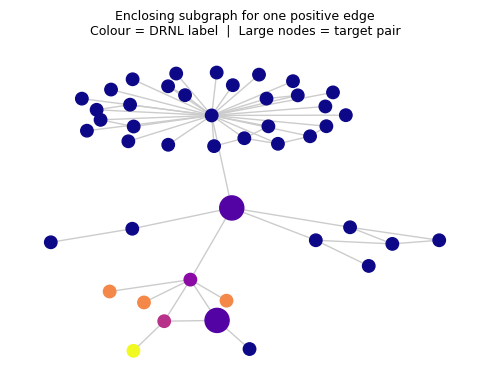

In [20]:
# Inspect one subgraph
ex = train_pos[0]
print("Example positive subgraph:")
print(f"  Nodes           : {ex.num_nodes}")
print(f"  Edges           : {ex.num_edges}")
print(f"  Feature dim     : {ex.x.shape[1]}  "
      f"(= {seal_dataset.num_features} node features + 200 DRNL one-hot dims)")
print(f"  Label           : {ex.y}  (1 = positive edge)")
print(f"  DRNL z-labels   : {ex.z.tolist()}")
print()
# Visualise the subgraph, colouring nodes by their DRNL label
G_ex  = to_networkx(ex, to_undirected=True)
pos_g = nx.spring_layout(G_ex, seed=1)
colors = [ex.z[n].item() for n in G_ex.nodes()]

plt.figure(figsize=(5, 4))
nx.draw_networkx(G_ex, pos=pos_g, with_labels=False,
                 node_color=colors, cmap='plasma',
                 node_size=[300 if ex.z[n] == 1 else 80 for n in G_ex.nodes()],
                 edge_color='#cccccc')
plt.title("Enclosing subgraph for one positive edge\n"
          "Colour = DRNL label  |  Large nodes = target pair", fontsize=9)
plt.axis('off')
plt.tight_layout()
plt.show()

In [21]:
# ── Step 3: DataLoaders ───────────────────────────────────────────────────
train_set = train_pos + train_neg
val_set   = val_pos   + val_neg
test_set  = test_pos  + test_neg

seal_train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
seal_val_loader   = DataLoader(val_set,   batch_size=32)
seal_test_loader  = DataLoader(test_set,  batch_size=32)

print(f"Train subgraphs: {len(train_set)}  "
      f"({len(train_pos)} positive + {len(train_neg)} negative)")
print(f"Val   subgraphs: {len(val_set)}")
print(f"Test  subgraphs: {len(test_set)}")
print(f"Feature dim    : {train_set[0].num_features}")

Train subgraphs: 8976  (4488 positive + 4488 negative)
Val   subgraphs: 526
Test  subgraphs: 1054
Feature dim    : 1633


### DGCNN: the graph classifier

SEAL uses **DGCNN** (Zhang et al., 2018) as its graph-level classifier.  DGCNN
combines:

1. **Multiple GCN layers** that compute node embeddings at different depths.
2. **SortPooling** — a global aggregation that sorts nodes by their final-layer
   activations and keeps the top-*k*, producing a fixed-size graph representation.
3. **1-D convolution** over the sorted sequence (treating the graph representation
   like a time-series).
4. A dense MLP classifier.

The `k` parameter in SortPooling controls how many nodes are retained.
A common heuristic is to set `k` to the 60th percentile of graph sizes in the dataset.


In [22]:
from torch.nn import Conv1d, MaxPool1d, Linear, Dropout, BCEWithLogitsLoss
from torch_geometric.nn import GCNConv, aggr as pyg_aggr

# Determine k: 60th percentile of training graph sizes
sizes = sorted([d.num_nodes for d in train_set])
k = max(10, sizes[int(0.6 * len(sizes))])
print(f"SortPooling k = {k}  (60th percentile of subgraph sizes)")

class DGCNN(torch.nn.Module):
    def __init__(self, dim_in: int, k: int = 30):
        super().__init__()
        # GCN layers (4 layers with output dims 32, 32, 32, 1)
        self.gcn1 = GCNConv(dim_in, 32)
        self.gcn2 = GCNConv(32,     32)
        self.gcn3 = GCNConv(32,     32)
        self.gcn4 = GCNConv(32,      1)

        # SortPooling: keep top-k nodes
        self.global_pool = pyg_aggr.SortAggregation(k=k)

        # 1-D convolution over the sorted sequence
        # Total feature dim per node: 32+32+32+1 = 97
        self.conv1   = Conv1d(1,  16, 97, 97)
        self.conv2   = Conv1d(16, 32,  5,  1)
        self.maxpool = MaxPool1d(2, 2)

        # Compute linear input size from k so this works for any k:
        #   after conv1+maxpool : (B, 16, k//2)
        #   after conv2         : (B, 32, k//2 - 4)
        #   after flatten       : (B, 32 * (k//2 - 4))
        lin_in = 32 * (k // 2 - 4)
        self.linear1 = Linear(lin_in, 128)
        self.dropout = Dropout(0.5)
        self.linear2 = Linear(128, 1)

    def forward(self, x, edge_index, batch):
        h1 = self.gcn1(x, edge_index).tanh()
        h2 = self.gcn2(h1, edge_index).tanh()
        h3 = self.gcn3(h2, edge_index).tanh()
        h4 = self.gcn4(h3, edge_index).tanh()
        h  = torch.cat([h1, h2, h3, h4], dim=-1)

        h  = self.global_pool(h, batch)

        h  = h.view(h.size(0), 1, h.size(-1))
        h  = self.conv1(h).relu()
        h  = self.maxpool(h)
        h  = self.conv2(h).relu()
        h  = h.view(h.size(0), -1)

        h  = self.linear1(h).relu()
        h  = self.dropout(h)
        h  = self.linear2(h)
        return h.squeeze(-1)

# Instantiate
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seal_model  = DGCNN(dim_in=train_set[0].num_features, k=k).to(device)
print(seal_model)
print(f"Parameters: {sum(p.numel() for p in seal_model.parameters()):,}")

SortPooling k = 49  (60th percentile of subgraph sizes)
DGCNN(
  (gcn1): GCNConv(1633, 32)
  (gcn2): GCNConv(32, 32)
  (gcn3): GCNConv(32, 32)
  (gcn4): GCNConv(32, 1)
  (global_pool): SortAggregation(k=49)
  (conv1): Conv1d(1, 16, kernel_size=(97,), stride=(97,))
  (conv2): Conv1d(16, 32, kernel_size=(5,), stride=(1,))
  (maxpool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (linear1): Linear(in_features=640, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (linear2): Linear(in_features=128, out_features=1, bias=True)
)
Parameters: 140,770


In [23]:
seal_optimizer = torch.optim.Adam(seal_model.parameters(), lr=1e-4)
seal_criterion = BCEWithLogitsLoss()

def seal_train():
    seal_model.train()
    total_loss = 0
    for data in seal_train_loader:
        data = data.to(device)
        seal_optimizer.zero_grad()
        out  = seal_model(data.x, data.edge_index, data.batch)
        loss = seal_criterion(out, data.y.float())
        loss.backward()
        seal_optimizer.step()
        total_loss += float(loss) * data.num_graphs
    return total_loss / len(train_set)

@torch.no_grad()
def seal_test(loader):
    seal_model.eval()
    y_pred, y_true = [], []
    for data in loader:
        data = data.to(device)
        out  = seal_model(data.x, data.edge_index, data.batch)
        y_pred.append(out.cpu())
        y_true.append(data.y.float().cpu())
    y_pred = torch.cat(y_pred);  y_true = torch.cat(y_true)
    auc = roc_auc_score(y_true.numpy(), y_pred.numpy())
    ap  = average_precision_score(y_true.numpy(), y_pred.numpy())
    return auc, ap

for epoch in range(31):    # set to 101 for full training
    loss = seal_train()
    val_auc, val_ap = seal_test(seal_val_loader)
    if epoch % 5 == 0:
        print(f"Epoch {epoch:>2} | Loss: {loss:.4f} | "
              f"Val AUC: {val_auc:.4f} | Val AP: {val_ap:.4f}")

seal_test_auc, seal_test_ap = seal_test(seal_test_loader)
print(f"\nSEAL  Test AUC: {seal_test_auc:.4f} | Test AP: {seal_test_ap:.4f}")

Epoch  0 | Loss: 0.6452 | Val AUC: 0.8316 | Val AP: 0.8312
Epoch  5 | Loss: 0.3693 | Val AUC: 0.9006 | Val AP: 0.9143
Epoch 10 | Loss: 0.2960 | Val AUC: 0.9082 | Val AP: 0.9245
Epoch 15 | Loss: 0.2581 | Val AUC: 0.9042 | Val AP: 0.9215
Epoch 20 | Loss: 0.2365 | Val AUC: 0.8946 | Val AP: 0.9142
Epoch 25 | Loss: 0.2147 | Val AUC: 0.8911 | Val AP: 0.9120
Epoch 30 | Loss: 0.1970 | Val AUC: 0.8769 | Val AP: 0.9027

SEAL  Test AUC: 0.9079 | Test AP: 0.9264


---
## 6. Summary and Comparison

| Model | Decoder | AUC | AP | Notes |
|-------|---------|-----|----|-------|
| **VGAE** | dot product (fixed) | 0.8843 | 0.8719 | Probabilistic latent space; KL regularisation |
| **GraphSAGE + MLP** | trainable MLP | 0.8692 | 0.8941 | Inductive; fresh negative sampling each epoch |
| **SEAL** | graph classifier | 0.9079 | 0.9264 | Structural heuristics via DRNL; slower but captures topology |

### Questions to reflect on

1. VGAE uses a **fixed** dot-product decoder while our GraphSAGE model uses a
   **trainable** MLP decoder.  Under what conditions would you expect the fixed
   decoder to outperform the trained one?

2. In Task 3 we sample fresh negative edges **every epoch**.  What would happen
   if we fixed the negative set (sampled once before training)?  Is one approach
   always better?

3. SEAL is significantly slower than VGAE and GraphSAGE.  In which real-world
   scenarios would the extra compute be justified?

4. We used `num_neg_samples = num_pos_edges` (balanced training).  Real graphs
   are extremely sparse — there are orders of magnitude more non-edges than
   edges.  How should evaluation reflect this imbalance?

   This is a clean written answer — not a document request — so I'll write it directly in the chat as polished English prose rather than creating a file.

---

**Question 1.** 
The dot-product decoder outperforms a trainable MLP when the encoder's embedding space already encodes similarity in a way that is naturally captured by the inner product. Several conditions favor this: first, when the dataset is small, the MLP's additional parameters lead to overfitting, while the parameter-free dot product does not. Second, when the graph has homogeneous, single-principle connectivity — such as topical similarity in citation networks — the angular distance in embedding space fully explains edge formation, leaving nothing for the MLP to learn. Third, and most importantly for VGAE specifically: the KL regularization term forces the encoder to map nodes into $\mathcal{N}(0, I)$, a space where the inner product is the natural similarity measure. The encoder is therefore trained end-to-end with the dot-product decoder in mind, making a replacement MLP redundant. In general, when the encoder is expressive enough and the data is structurally simple, the fixed decoder is not a bottleneck — and adding learnable parameters only introduces unnecessary variance.

---

**Question 2.**

With a fixed negative set sampled once before training, the model gradually memorizes those specific node pairs rather than learning to generalize the concept of "absent edge." This is a form of overfitting to the negative partition. If the fixed negatives happen to be easy — pairs of nodes from clearly different communities — the model never encounters hard negatives (structurally similar nodes without an edge) and will produce an overoptimistic AUC on the training distribution. Re-sampling fresh negatives every epoch, as implemented in Task 3, exposes the model to a much broader portion of the negative space and acts as a form of data augmentation, improving generalization.

That said, fresh sampling is not unconditionally superior. In a curriculum learning framework it can be beneficial to start with easy negatives and gradually introduce harder ones, rather than sampling uniformly from the start. Fixed negatives also improve reproducibility, which matters for controlled ablation studies. The optimal strategy is therefore task-dependent: dynamic sampling is the better default for generalization, but structured negative curricula can accelerate convergence on difficult graphs.

---

**Question 3.** 

SEAL's key advantage is that it explicitly captures local structural patterns around each candidate edge through Double-Radius Node Labelling, rather than relying solely on global node embeddings. This makes it particularly valuable in the following settings. In social networks, the triadic closure principle — if A knows B and B knows C, then A and C are likely to connect — is a structural signal that dot-product decoders cannot directly model, but DRNL encodes through distance information. In biological networks such as protein-protein interaction graphs or drug-target interaction networks, the binding relationship between two proteins often depends on the local network motif they participate in, not on their global position in the graph. In knowledge graph completion, structural patterns like symmetry, inversion, and transitivity are relational and local in nature. Finally, SEAL is naturally inductive for new nodes, since subgraph extraction and DRNL labeling require no global embedding — a critical property for dynamic graphs where new nodes appear continuously and retraining a full encoder is prohibitively expensive.

---

**Question 4.**

Training with a balanced 1:1 positive-to-negative ratio is a pragmatic choice for gradient stability, but it does not reflect reality. In a graph with $N$ nodes and $|E|$ edges, the true positive rate among all candidate pairs is approximately $2|E|/N^2$ — for Cora this is around 0.14%, meaning roughly 700 non-edges exist for every true edge.

Evaluation should account for this in several ways. Average Precision (AP) is more informative than AUC under severe class imbalance: AUC can remain high even for weak models because most negatives are trivially separable, whereas AP directly penalizes poor precision at the top of the ranked list. Hits@K measures how many true edges appear in the top-K predictions, which directly reflects real-world utility — in a recommendation system, only the top-K suggestions are ever shown to the user. The negative sampling ratio at test time should also be made more realistic: evaluating at 1:1 produces scores that are far more optimistic than what a deployed model will encounter at, say, 100:1 or 1000:1. In summary, a model that achieves excellent AUC under balanced evaluation can still fail in production if it cannot confidently rank rare positive edges above thousands of competing non-edges.
